In [23]:
from os import PathLike

import grain.python as grain
import numpy as np
import zarr
from jaxtyping import Shaped


class VAESource(grain.RandomAccessDataSource):
    def __init__(self, path: str | PathLike):
        z = zarr.open_group(path, mode="r")
        self.obs: zarr.Array = z["obs"]  # type: ignore

        shape = self.obs.shape
        self.n_episodes = shape[0]
        self.n_timesteps = shape[1]
        self.n_samples = self.n_episodes * self.n_timesteps

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Shaped[np.ndarray, "H W C"]:
        # We use divmod here as the inverse equivalent of...
        #   ix = ep_ix * num_timesteps + time_ix
        ep_idx, time_idx = divmod(idx, self.n_timesteps)
        return np.asarray(self.obs[ep_idx, time_idx])

In [24]:
import jax.numpy as jnp
from flax import nnx

from wm.initializer import cauchy_initializer

init = cauchy_initializer(0.01)

linear = nnx.Linear(24, 24, kernel_init=init, rngs=nnx.Rngs(0))

x = jnp.linspace(0, 1, num=24)
linear(x)

Array([ 0.05004337, -0.09323561,  0.11513612, -0.12478059, -0.080755  ,
       -0.05415966,  0.02237166,  0.03130406,  0.16104871,  0.1225068 ,
       -0.24414736, -0.0277194 ,  0.16924098, -0.02767498, -0.12597284,
       -1.413184  , -0.1382136 ,  0.0361471 , -0.07650487,  0.5192707 ,
        0.05243022, -0.30276522,  0.06155603,  0.08422362], dtype=float32)

In [25]:
# import gymnasium as gym
# from tqdm import trange

# from wm import Agent
# from wm.utils import normalise_obs, prep_obs

# num_envs = 1
# envs = gym.make_vec("CarRacing-v3", num_envs=num_envs)

# for seed in trange(0, 1000):
#     agent = Agent(rngs=nnx.Rngs(seed))
#     states, _ = envs.reset(seed=seed)
#     o = prep_obs(states)
#     # Instantiate data containers for a give rollout - which we'll then append to our
#     # persistent data store
#     rollout_obs = np.zeros(shape=(num_envs, 1001, 64, 64, 3), dtype=np.uint8)
#     rollout_act = np.zeros(shape=(num_envs, 1000, 3), dtype=np.float32)
#     rollout_obs[:, 0] = o

#     carry = agent.initialize_carry(num_envs)

#     for t in range(10):
#         a, carry = agent(normalise_obs(o), carry)  # type: ignore
#         states, rewards, truncateds, terminateds, infos = envs.step(np.array(a))
#         o = prep_obs(states)

#         # We shift the observation by one (recording 1,001) so we
#         # can store both the initial and final observation
#         rollout_obs[:, t + 1] = o
#         rollout_act[:, t] = a

 74%|███████▍  | 740/1000 [00:58<00:20, 12.66it/s]


KeyboardInterrupt: 

In [26]:
from absl import flags

FLAGS = flags.FLAGS

if not FLAGS.is_parsed():
    FLAGS(["notebook"])

In [38]:
import einops

data_path = "../data/vae"
z = zarr.open_group(data_path, mode="r")
example_eps = z["obs"][:64]
example_acts = z["act"][:64]
example_acts = einops.rearrange(example_acts, "b t a -> a (b t)")

(array([2.7628e+04, 0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00, 3.6365e+04]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

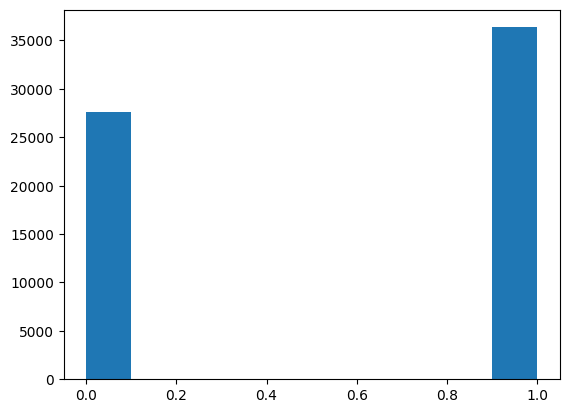

In [43]:
import matplotlib.pyplot as plt

plt.hist(example_acts[2])

In [45]:
import mediapy as media

media.show_video(example_eps[0], height=64 * 4, width=64 * 4, fps=90)

This browser does not support the video tag.


In [ ]:
example_acts[4]

array([[ 0.6144079 ,  0.585783  ,  0.43082407],
       [ 0.49311408,  0.39677233,  0.6071757 ],
       [-0.05945058,  0.37152642,  0.36676037],
       ...,
       [ 0.07796147,  0.27446622,  0.47359693],
       [ 0.40635788,  0.33949965,  0.50639623],
       [-0.05722178,  0.73765016,  0.5623024 ]],
      shape=(1000, 3), dtype=float32)